In [14]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import random
random.seed(42)

### Analyze, why documents tagged with "sarcasm" are not sarcastic according to model

In [15]:
p2r = Path("../results/LLM_as_judge/QueryDocMatch_raw.jsonl")
p2h = Path("../results/LLM_as_judge/QueryDocMatch_harm.jsonl")

def read_jsonl(path):
    data = []
    with path.open("r") as f:
        for line in f:
            data.append(json.loads(line))

    return data

raw_responses = read_jsonl(p2r)

In [16]:
explanations_for_no = []
for response in raw_responses:
    if response["response"].lower().strip("* ").endswith("answer: no"):
        explanations_for_no.append(response["response"])

print(len(explanations_for_no))

1607


In [64]:
random.sample(explanations_for_no, k=20)

["The document is a detailed, heartfelt, and enthusiastic account of receiving an overwhelming number of thoughtful gifts from a friend (Cheryl), followed by the unexpected adoption of a stray dog named Edward. The tone is warm, grateful, and at times humorous — especially in the description of the dog’s behavior (“he considers himself a stud,” “he threw up in my car. Multiple times,” “Bleck!”).\n\nHowever, **there is no sarcasm or irony** in the writing. The author expresses genuine appreciation for the gifts and genuine concern and affection for the dog. Even the more exaggerated or humorous parts — like listing 12+ items in the package or joking about the dog’s “hoo-hoos” — are delivered with sincerity and affection, not as ironic or sarcastic commentary. The phrase “I am not worthy of such riches, but I'm going to keep them anyway!” is hyperbolic gratitude, not sarcasm. The dog’s situation is treated with emotional weight, not mockery.\n\nSarcasm requires a contrast between what is

### Plot how similarity to query maps to model aproval of descriptor and of document

In [18]:
query_doc_match_raw = Path("../results/LLM_as_judge/QueryDocMatch_raw.jsonl")
query_doc_match_harm = Path("../results/LLM_as_judge/QueryDocMatch_harmonized.jsonl")

raw_search_results = Path("../results/faiss/raw_search_results.jsonl")
harm_search_results = Path("../results/faiss/harmonized_search_results.jsonl")

model_validated_descriptors_raw = Path("../results/LLM_as_judge/sarcasm_descriptor_correspondence_raw.jsonl")
model_validated_descriptors_harm = Path("../results/LLM_as_judge/sarcasm_descriptor_correspondence_harmonized.jsonl")

model_validated_docs_raw = Path("../results/faiss/valid_sarcasm_docs_raw.txt")
model_validated_docs_harm = Path("../results/faiss/valid_sarcasm_docs_harmonized.txt")



raw_responses = read_jsonl(query_doc_match_raw)
harm_responses = read_jsonl(query_doc_match_harm)

raw_search_results = read_jsonl(raw_search_results)
harm_search_results = read_jsonl(harm_search_results)

raw_descriptors = read_jsonl(model_validated_descriptors_raw)
harm_descriptors = read_jsonl(model_validated_descriptors_harm)

with open(model_validated_docs_raw, "r") as r, open(model_validated_docs_harm, "r") as h:
    raw_docs = [d.strip() for d in r.readlines()]
    harm_docs = [d.strip() for d in h.readlines()]

In [19]:
# Fish out model validated descriptor from LLM responses
def get_validated_descriptors(responses):
    validated = []
    for response in responses:
        if response["response"].lower().strip("* ").endswith("answer: yes"):
            validated.append(response["example"]["descriptor"])

    return validated

validated_raw_descriptors = get_validated_descriptors(raw_descriptors)
validated_harm_descriptors = get_validated_descriptors(harm_descriptors)

In [20]:
def descriptor_distances(search_results):
    distances = []
    for desc in search_results[0]["results"]:
        dist = desc["distance"]
        descriptor = desc["descriptor"]
        distances.append((dist, descriptor))
    return distances

raw_distances = descriptor_distances(raw_search_results)
harm_distances = descriptor_distances(harm_search_results)

In [25]:
def validated_descriptor_to_doc_mapping(search_results, validated_descriptors):
    descriptors_and_docs = {}
    for desc in search_results[0]["results"]:
        descriptor = desc["descriptor"]
        if descriptor in validated_descriptors:
            docs = []
            for doc in desc["documents"]:
                docs.append(doc["text"])
            descriptors_and_docs[descriptor] = docs
            
    return descriptors_and_docs

descriptors_and_docs_raw = validated_descriptor_to_doc_mapping(raw_search_results, validated_raw_descriptors)
descriptors_and_docs_harm = validated_descriptor_to_doc_mapping(harm_search_results, validated_harm_descriptors)

In [42]:
def get_validated_docs(responses, desc2doc):
    doc_acceptance_by_desc = {}
    for descriptor in desc2doc:
        documents_accepted = 0
        documents_rejected = 0
        descriptor_docs = desc2doc[descriptor]
        for doc in descriptor_docs:
            for response in responses:
                
                response_doc = response["example"]["document"]
                if doc == response_doc:
                    if response["response"].lower().strip("* ").endswith("answer: yes"):
                        documents_accepted += 1
                    else:
                        documents_rejected += 1
        doc_acceptance_by_desc[descriptor] = {"accepted": documents_accepted, "rejected": documents_rejected}
            

    return doc_acceptance_by_desc
            
    

raw_docs_acceptance_by_desc = get_validated_docs(raw_responses, descriptors_and_docs_raw)
harm_docs_acceptance_by_desc = get_validated_docs(harm_responses, descriptors_and_docs_harm)

In [59]:
import matplotlib.pyplot as plt

def plot_validation_distribution(validated, double_validated_dict, all_items, descriptor_type = None, save_path=None, bin_count=10):
    # Extract strings and distances from the 'all' list
    strings = [item[1] for item in all_items]
    distances = [item[0] for item in all_items]

    # Create list indicating single validation status
    is_validated = [s in validated for s in strings]

    # Prepare double validation data (accepted and rejected counts)
    double_validated_data = []
    for s in strings:
        if s in double_validated_dict:
            data = double_validated_dict[s]
            double_validated_data.append((data['accepted'], data['rejected']))
        else:
            double_validated_data.append((0, 0))

    # Sort by distance and divide into bins
    sorted_data = sorted(zip(distances, is_validated, double_validated_data),
                        key=lambda x: x[0])
    total = len(sorted_data)
    bin_size = total // bin_count

    # Calculate rates for each bin
    validated_rates = []
    double_validated_rates = []

    for i in range(bin_count):
        start = i * bin_size
        end = (i + 1) * bin_size if i < bin_count - 1 else total
        bin_items = sorted_data[start:end]

        # Single validation rate
        validated_count = sum(1 for _, is_val, _ in bin_items if is_val)
        validated_rates.append((validated_count / len(bin_items)) * 100)

        # Double validation acceptance rate
        total_accepted = sum(acc for _, _, (acc, rej) in bin_items)
        total_rejected = sum(rej for _, _, (acc, rej) in bin_items)
        total_votes = total_accepted + total_rejected

        if total_votes > 0:
            double_validated_rates.append((total_accepted / total_votes) * 100)
        else:
            double_validated_rates.append(0)

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Bar plot for single validated
    bars = ax.bar(range(bin_count), validated_rates,
                  color='skyblue', alpha=0.7, label='Descriptors')

    # Line plot for double validated acceptance rate
    line = ax.plot(range(bin_count), double_validated_rates,
                   color='red', marker='o', linewidth=2, markersize=8,
                   label='Documents')

    # Customize the plot
    if descriptor_type:
        if descriptor_type.lower() == "raw":
            ax.set_title("Unharmonized descriptors", fontsize=14, pad=20)
        else:
            ax.set_title("Harmonized descriptors", fontsize=14, pad=20)
    ax.set_xlabel("Similarity Decile Groups", fontsize=14, labelpad=10)
    ax.set_ylabel("LLM Acceptance Rate (%)", fontsize=14, labelpad=10)
    ax.set_xticks(range(bin_count))
    #ax.set_xticklabels([f"{i*10}-{(i+1)*10}%" for i in range(bin_count)])
    ax.set_xticklabels([i+1 for i in range(bin_count)])
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(fontsize=12)

    # Add value labels for bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10)

    # Add value labels for line points
    for i, (x, y) in enumerate(zip(range(bin_count), double_validated_rates)):
        ax.text(x, y + 3, f'{y:.1f}%',
                ha='center', va='bottom', fontsize=10, color='red')

    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

Plot saved to ../figures/LLM_sarcasm_acceptance_harmonized.png


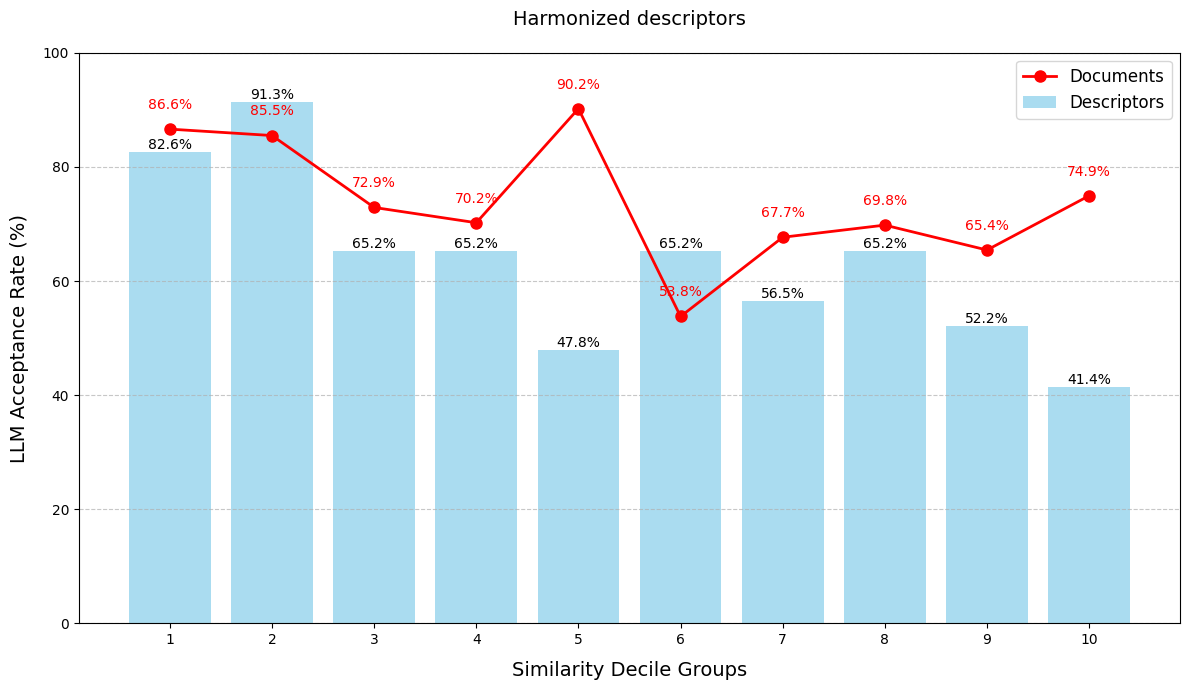

In [60]:
plot_validation_distribution(
    validated_harm_descriptors,
    harm_descriptors_with_validated_docs,
    harm_distances,
    descriptor_type = "harmonized",
    save_path = Path("../figures/LLM_sarcasm_acceptance_harmonized.png")
)

Plot saved to ../figures/LLM_sarcasm_acceptance_raw.png


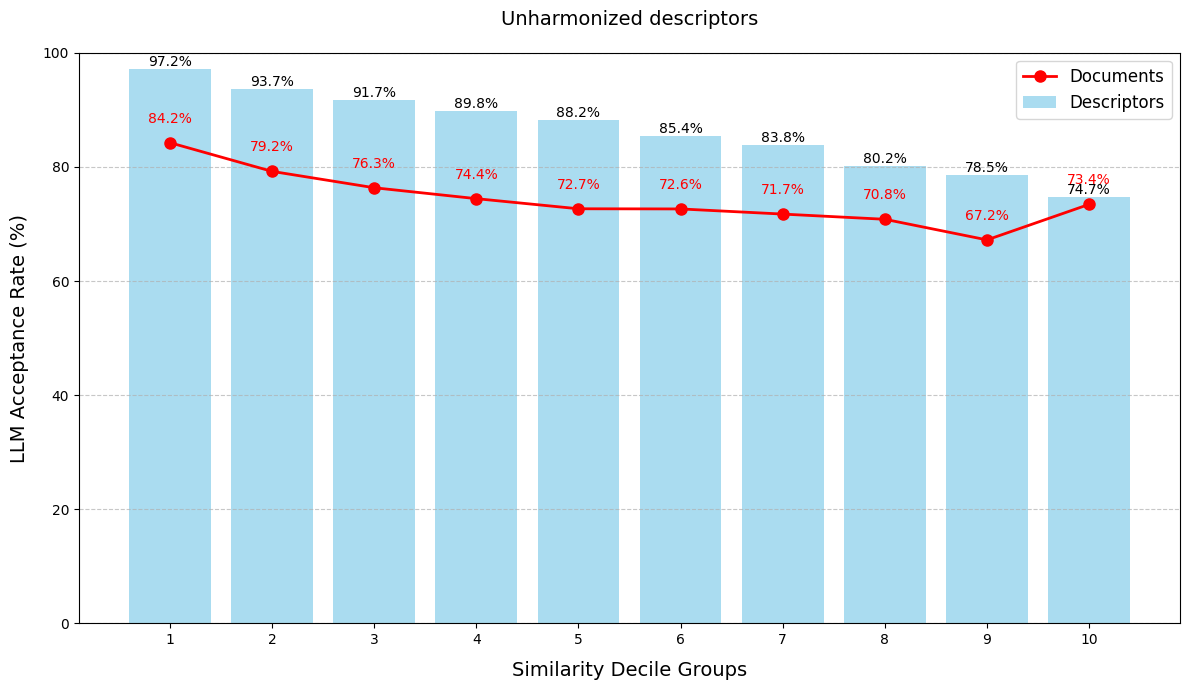

In [63]:
plot_validation_distribution(
    validated_raw_descriptors,
    raw_descriptors_with_validated_docs,
    raw_distances,
    descriptor_type = "raw",
    save_path = Path("../figures/LLM_sarcasm_acceptance_raw.png")
)